# BiLSTM: Sequence-Based Neural Model

This notebook trains a Bidirectional LSTM (BiLSTM) for the mental-health text classification experiment.

The same fixed train, validation, and test splits from `02_dataset_preparation.ipynb` are used so that the BiLSTM can be compared fairly with the TF-IDF baseline.

## Research purpose

The BiLSTM provides a sequence-based neural baseline. Unlike TF-IDF, it processes token sequences and learns an embedding representation together with bidirectional contextual information.

## 1. Import libraries

In [1]:
from pathlib import Path
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

## 2. Set random seeds and device

The random seed is fixed to make the experiment reproducible. CUDA is used automatically if it is available.

In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 3. Load the fixed dataset splits

In [3]:
possible_dirs = [
    Path("data/prepared"),
    Path("../data/prepared")
]

DATA_DIR = None

for directory in possible_dirs:
    if (directory / "train.csv").exists():
        DATA_DIR = directory
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the prepared dataset. "
        "Please run 02_dataset_preparation.ipynb first."
    )

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("Training set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

Training set: (38115, 2)
Validation set: (8167, 2)
Test set: (8168, 2)


## 4. Create label mappings

The labels are converted to integer IDs for PyTorch. The mapping is created from the complete set of labels in the prepared data and remains fixed throughout the experiment.

In [4]:
labels = sorted(train_df["label"].unique())

label_to_id = {label: i for i, label in enumerate(labels)}
id_to_label = {i: label for label, i in label_to_id.items()}

print("Label mapping:")
for label, label_id in label_to_id.items():
    print(label_id, "->", label)

Label mapping:
0 -> Anxiety
1 -> Depression
2 -> Happy
3 -> Mentalhealth
4 -> Normal
5 -> Sad
6 -> Stress
7 -> Suicidal


## 5. Build a vocabulary from the training data

The vocabulary is learned only from the training texts. Validation and test texts are therefore not used to build the vocabulary.

In [5]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

MAX_VOCAB_SIZE = 50000
MIN_FREQ = 2

counter = Counter()

for text in train_df["text"]:
    tokens = str(text).lower().split()
    counter.update(tokens)

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for word, frequency in counter.most_common():
    if frequency < MIN_FREQ:
        break
    if len(vocab) >= MAX_VOCAB_SIZE:
        break
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Vocabulary size: 41560


## 6. Convert text into padded token sequences

A maximum sequence length of 128 tokens is used, matching the sequence length used in the previous project implementation. Longer texts are truncated and shorter texts are padded.

In [6]:
MAX_LEN = 128

def encode_text(text):
    tokens = str(text).lower().split()
    token_ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens]
    token_ids = token_ids[:MAX_LEN]

    if len(token_ids) < MAX_LEN:
        token_ids += [vocab[PAD_TOKEN]] * (MAX_LEN - len(token_ids))

    return token_ids




## 7. Create PyTorch datasets and data loaders

In [7]:
class MentalHealthDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["text"].tolist()
        self.labels = [label_to_id[label] for label in dataframe["label"]]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        input_ids = torch.tensor(encode_text(self.texts[index]), dtype=torch.long)
        label = torch.tensor(self.labels[index], dtype=torch.long)
        return input_ids, label


train_dataset = MentalHealthDataset(train_df)
val_dataset = MentalHealthDataset(val_df)
test_dataset = MentalHealthDataset(test_df)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1192
Validation batches: 256
Test batches: 256


## 8. Define the BiLSTM model

The architecture is: embedding → bidirectional LSTM → mean pooling over non-padding tokens → dropout → linear classifier.

In [8]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=vocab[PAD_TOKEN]
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        mask = (input_ids != vocab[PAD_TOKEN]).unsqueeze(-1)

        embedded = self.embedding(input_ids)
        lstm_output, _ = self.lstm(embedded)

        lstm_output = lstm_output * mask
        lengths = mask.sum(dim=1).clamp(min=1)
        pooled = lstm_output.sum(dim=1) / lengths

        pooled = self.dropout(pooled)
        return self.classifier(pooled)


EMBEDDING_DIM = 100
HIDDEN_DIM = 128
DROPOUT = 0.3
NUM_CLASSES = len(labels)

model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(device)

print(model)

BiLSTMClassifier(
  (embedding): Embedding(41560, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=8, bias=True)
)


## 9. Handle class imbalance

The training set is imbalanced. We use inverse-frequency class weights in the cross-entropy loss so that minority classes contribute more strongly to the training objective.

In [9]:
class_counts = train_df["label"].value_counts().reindex(labels)
class_weights = len(train_df) / (len(labels) * class_counts.values)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:")
for label, weight in zip(labels, class_weights.cpu().numpy()):
    print(f"{label}: {weight:.4f}")

Class weights:
Anxiety: 1.4879
Depression: 0.4300
Happy: 9.9465
Mentalhealth: 3.5006
Normal: 0.4246
Sad: 4.1538
Stress: 2.9703
Suicidal: 0.5941


## 10. Training setup

In [10]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 5

print("Epochs:", EPOCHS)
print("Learning rate:", 0.001)
print("Batch size:", BATCH_SIZE)

Epochs: 5
Learning rate: 0.001
Batch size: 32


## 11. Evaluation function

In [11]:
def evaluate_model(model, data_loader):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels_batch in data_loader:
            input_ids = input_ids.to(device)
            outputs = model(input_ids)
            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels_batch.numpy())

    return np.array(all_labels), np.array(all_predictions)

## 12. Train the BiLSTM

The validation Macro F1 is monitored after each epoch. The model state with the best validation Macro F1 is restored before final test evaluation.

In [12]:
best_val_f1 = -1.0
best_model_state = None
history = []

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for input_ids, labels_batch in train_loader:
        input_ids = input_ids.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    y_val_ids, y_val_pred_ids = evaluate_model(model, val_loader)
    val_macro_f1 = f1_score(
        y_val_ids,
        y_val_pred_ids,
        average="macro",
        zero_division=0
    )

    average_loss = running_loss / len(train_loader)
    history.append({
        "epoch": epoch + 1,
        "train_loss": average_loss,
        "val_macro_f1": val_macro_f1
    })

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {average_loss:.4f} | "
        f"Validation Macro F1: {val_macro_f1:.4f}"
    )

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

training_time = time.time() - start_time

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"Training completed in {training_time:.2f} seconds.")
print(f"Best validation Macro F1: {best_val_f1:.4f}")

Epoch 1/5 | Loss: 1.1474 | Validation Macro F1: 0.5555
Epoch 2/5 | Loss: 0.7519 | Validation Macro F1: 0.6394
Epoch 3/5 | Loss: 0.5760 | Validation Macro F1: 0.6526
Epoch 4/5 | Loss: 0.4517 | Validation Macro F1: 0.6578
Epoch 5/5 | Loss: 0.3532 | Validation Macro F1: 0.6643
Training completed in 61.77 seconds.
Best validation Macro F1: 0.6643


## 13. Plot training progress

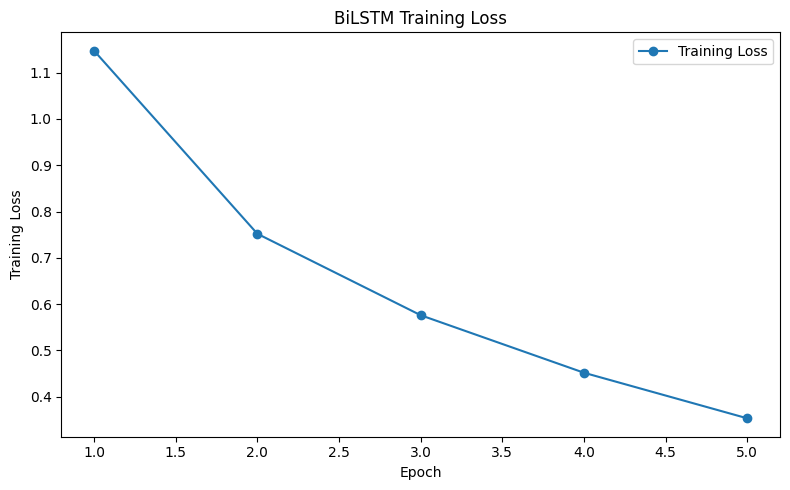

In [13]:
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("BiLSTM Training Loss")
ax.legend()
plt.tight_layout()
plt.show()

## 14. Final test evaluation

In [14]:
y_test_ids, y_test_pred_ids = evaluate_model(model, test_loader)

y_test_labels = [id_to_label[i] for i in y_test_ids]
y_test_pred_labels = [id_to_label[i] for i in y_test_pred_ids]

test_accuracy = accuracy_score(y_test_labels, y_test_pred_labels)
test_macro_precision = precision_score(
    y_test_labels, y_test_pred_labels, average="macro", zero_division=0
)
test_macro_recall = recall_score(
    y_test_labels, y_test_pred_labels, average="macro", zero_division=0
)
test_macro_f1 = f1_score(
    y_test_labels, y_test_pred_labels, average="macro", zero_division=0
)
test_weighted_f1 = f1_score(
    y_test_labels, y_test_pred_labels, average="weighted", zero_division=0
)

print("BiLSTM Test Results")
print("-------------------")
print(f"Accuracy:          {test_accuracy:.4f}")
print(f"Macro Precision:   {test_macro_precision:.4f}")
print(f"Macro Recall:      {test_macro_recall:.4f}")
print(f"Macro F1:          {test_macro_f1:.4f}")
print(f"Weighted F1:       {test_weighted_f1:.4f}")

BiLSTM Test Results
-------------------
Accuracy:          0.7178
Macro Precision:   0.6262
Macro Recall:      0.6705
Macro F1:          0.6425
Weighted F1:       0.7227


## 15. Per-class performance

In [15]:
report = classification_report(
    y_test_labels,
    y_test_pred_labels,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

     Anxiety       0.77      0.76      0.76       687
  Depression       0.72      0.64      0.68      2375
       Happy       0.62      0.60      0.61       102
Mentalhealth       0.53      0.61      0.57       292
      Normal       0.92      0.88      0.90      2405
         Sad       0.41      0.58      0.48       246
      Stress       0.42      0.65      0.51       343
    Suicidal       0.62      0.64      0.63      1718

    accuracy                           0.72      8168
   macro avg       0.63      0.67      0.64      8168
weighted avg       0.73      0.72      0.72      8168



## 16. Confusion matrix

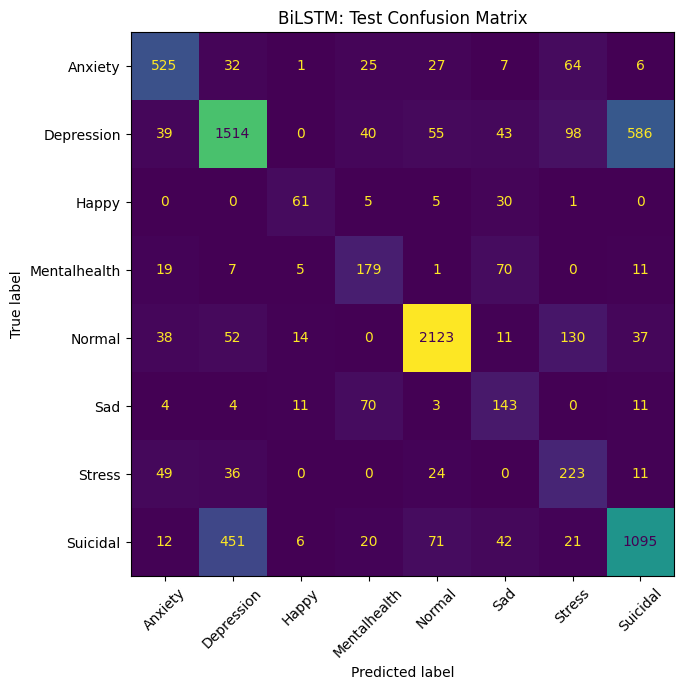

In [16]:
cm = confusion_matrix(
    y_test_labels,
    y_test_pred_labels,
    labels=labels
)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, values_format="d", colorbar=False)
plt.title("BiLSTM: Test Confusion Matrix")
plt.tight_layout()
plt.show()

## 17. Save BiLSTM results

The results are stored in the same results folder as the TF-IDF baseline.

In [17]:
results_dir = DATA_DIR.parent / "results"
results_dir.mkdir(parents=True, exist_ok=True)

bilstm_results = pd.DataFrame([{
    "model": "BiLSTM",
    "accuracy": test_accuracy,
    "macro_precision": test_macro_precision,
    "macro_recall": test_macro_recall,
    "macro_f1": test_macro_f1,
    "weighted_f1": test_weighted_f1,
    "best_validation_macro_f1": best_val_f1,
    "training_time_seconds": training_time,
    "n_train": len(train_df),
    "n_validation": len(val_df),
    "n_test": len(test_df),
    "vocab_size": len(vocab),
    "max_sequence_length": MAX_LEN,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": HIDDEN_DIM,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS
}])

bilstm_results.to_csv(results_dir / "bilstm_results.csv", index=False)
history_df.to_csv(results_dir / "bilstm_training_history.csv", index=False)

print("Saved results to:")
print(results_dir / "bilstm_results.csv")
print(results_dir / "bilstm_training_history.csv")

Saved results to:
..\data\results\bilstm_results.csv
..\data\results\bilstm_training_history.csv


## 18. Final summary

In [18]:
print("BiLSTM experiment completed.")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Best Validation Macro F1: {best_val_f1:.4f}")
print(f"Training time: {training_time:.2f} seconds")
print(f"Vocabulary size: {len(vocab)}")
print(f"Device: {device}")

BiLSTM experiment completed.
Test Macro F1: 0.6425
Test Accuracy: 0.7178
Best Validation Macro F1: 0.6643
Training time: 61.77 seconds
Vocabulary size: 41560
Device: cuda
